# Notebook 2 — M2: Semáforo de precio (KNN) + Random Forest

**Real Estate Intelligence Platform (REIP)**

Entrenamos el semáforo de precio de M2 (KNN sobre atributos estructurados, ya no proximidad
geográfica) y un Random Forest como comparación metodológica, sobre el mismo dataset y el mismo
split — no dos experimentos independientes. El Random Forest no es candidato a producción; su
`.feature_importances_` es el ranking de price drivers que documentamos como evidencia adicional,
no un modelo a desplegar.


## Verificación de entorno y rutas

**Dataset de entrada:** `pipeline/data/processed/catalogo_residencial_limpio_6_2_1.csv` (Notebook
6.2.1, con el enriquecimiento de `tipo_inmueble`/`descripcion` ya incorporado).

**Definición de "comparable":** corregimiento + tipo_inmueble, tal como quedó redefinida en
Notebook 6.2.1 — ya no proximidad geográfica (`geom` es sintético, nunca insumo de modelo).

**Zone Health:** confirmamos que no lo usamos como feature — decisión ya cerrada (colinealidad
perfecta con `corregimiento`, que ya es variable de agrupación aquí). No se cruza en ningún punto
de este notebook.

**Artifacts:** `pipeline/models/` (convención establecida en 6.2.1) para los modelos serializados.

**Exclusión de Pedregal y Parque Lefevre:** ya documentada y cerrada (Acta de Feature 1.2, §5.3) —
volumen insuficiente para 5-fold CV. No la reabrimos aquí, la aplicamos.


In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

REPO_ROOT = Path("..").resolve()
RUTA_CATALOGO = REPO_ROOT / "pipeline" / "data" / "processed" / "catalogo_residencial_limpio_6_2_1.csv"
RUTA_MODELOS = REPO_ROOT / "pipeline" / "models"
assert RUTA_CATALOGO.exists(), f"No existe {RUTA_CATALOGO}"
RUTA_MODELOS.mkdir(exist_ok=True)

RANDOM_STATE = 42


## 1. Carga y filtrado del dataset

In [2]:
df = pd.read_csv(RUTA_CATALOGO)
print(f"Catálogo completo: {len(df)} filas")

antes = len(df)
df = df[df["corregimiento"] != "zona_no_determinada"]
print(f"Tras excluir zona_no_determinada: {len(df)} ({antes - len(df)} descartadas)")

antes = len(df)
df = df[df["precio_no_evaluable"] == False]
print(f"Tras excluir precio_no_evaluable: {len(df)} ({antes - len(df)} descartadas)")

antes = len(df)
df = df[~df["corregimiento"].isin(["Pedregal", "Parque Lefevre"])]
print(f"Tras excluir Pedregal/Parque Lefevre (volumen insuficiente, Acta 1.2 §5.3): "
      f"{len(df)} ({antes - len(df)} descartadas)")


Catálogo completo: 1177 filas
Tras excluir zona_no_determinada: 1124 (53 descartadas)
Tras excluir precio_no_evaluable: 1110 (14 descartadas)
Tras excluir Pedregal/Parque Lefevre (volumen insuficiente, Acta 1.2 §5.3): 1091 (19 descartadas)


### 1.1 Contaminación de `tipo_inmueble` no detectada por el filtro de título — hallazgo nuevo

El filtro de título de Feature 1.2 (`TIPOS_EXCLUIDOS_KEYWORDS`) dejó pasar 4 registros que el
enriquecimiento de `tipo_inmueble` (Notebook 6.2.1, vía breadcrumb real de la página) revela como
no residenciales: un salón de belleza, un local comercial en inglés (*"Commercial Space"*, ya
documentado como hueco del filtro en español), un local para restaurante, y un terreno. Además,
`tipo_inmueble == "Edificios"` (5 registros) mezcla edificios residenciales pequeños con un hotel de
\$13,000,000 y un local comercial — con `bedrooms == 0` en 3 de los 5, señal de que son ventas de
edificio completo o espacio comercial, no unidades residenciales individuales comparables a las
demás filas del catálogo.


In [3]:
print(df["tipo_inmueble"].value_counts())
print()
print("Filas con tipo_inmueble no-Apartamentos y bedrooms==0 (venta de edificio completo o comercial):")
print(df.loc[(df["tipo_inmueble"] != "Apartamentos") & (df["bedrooms"] == 0),
             ["listing_id", "title", "tipo_inmueble", "price_usd", "area_m2"]])


tipo_inmueble
Apartamentos    1063
Casas             22
Edificios          4
Locales            2
Name: count, dtype: int64

Filas con tipo_inmueble no-Apartamentos y bedrooms==0 (venta de edificio completo o comercial):
     listing_id                                              title  \
687      141083             Casa Comercial en Venta en El Cangrejo   
688      142305             Casa Comercial en Venta en El Cangrejo   
689      142437                         Hotel en Venta El Cangrejo   
690      143089  Edificio Imperio en Venta  El Cangrejo, Ciuda...   
691      132175     Venta de local para restaurante en el cangrejo   

    tipo_inmueble  price_usd  area_m2  
687         Casas    1800000    900.0  
688         Casas    1800000    900.0  
689     Edificios   13000000   4026.0  
690     Edificios    3500000    781.0  
691       Locales     660000    407.0  


**Decisión de este notebook:** restringimos el pool de entrenamiento de KNN/RF a
`tipo_inmueble == "Apartamentos"` (1,140 de 1,177 filas del catálogo, ~97%). No es solo excluir los
4 casos de contaminación evidente — `"Casas"` (28) y `"Edificios"` (5) quedan fuera también, porque
mezclarlas introduce un problema de escala distinto al de contaminación de tipo: una casa o un
edificio completo no son comparables por precio/m² de la misma manera que un apartamento individual,
y el volumen de esas categorías (33 filas combinadas) es demasiado bajo para modelarlas por
separado con la misma disciplina de 5-fold CV ya aplicada a Pedregal/Parque Lefevre. La definición
de "comparable" de Notebook 6.2.1 (corregimiento + tipo_inmueble) se mantiene sin cambios — esta es
una decisión de alcance del pool de entrenamiento de 6.2.4, no una redefinición de comparable.


In [4]:
antes = len(df)
df = df[df["tipo_inmueble"] == "Apartamentos"]
print(f"Tras restringir a tipo_inmueble == 'Apartamentos': {len(df)} ({antes - len(df)} descartadas)")

antes = len(df)
df = df.dropna(subset=["area_m2"])
print(f"Tras descartar area_m2 nulo: {len(df)} ({antes - len(df)} descartadas)")

print(f"\nDataset final para KNN/RF: {len(df)} filas, {df['corregimiento'].nunique()} corregimientos")
df["corregimiento"].value_counts()


Tras restringir a tipo_inmueble == 'Apartamentos': 1063 (28 descartadas)
Tras descartar area_m2 nulo: 1042 (21 descartadas)

Dataset final para KNN/RF: 1042 filas, 7 corregimientos


corregimiento
San Francisco     451
Costa del Este    176
Bella Vista       174
El Cangrejo        72
Betania            61
Obarrio            59
Marbella           49
Name: count, dtype: int64

## 2. EDA de las variables del modelo

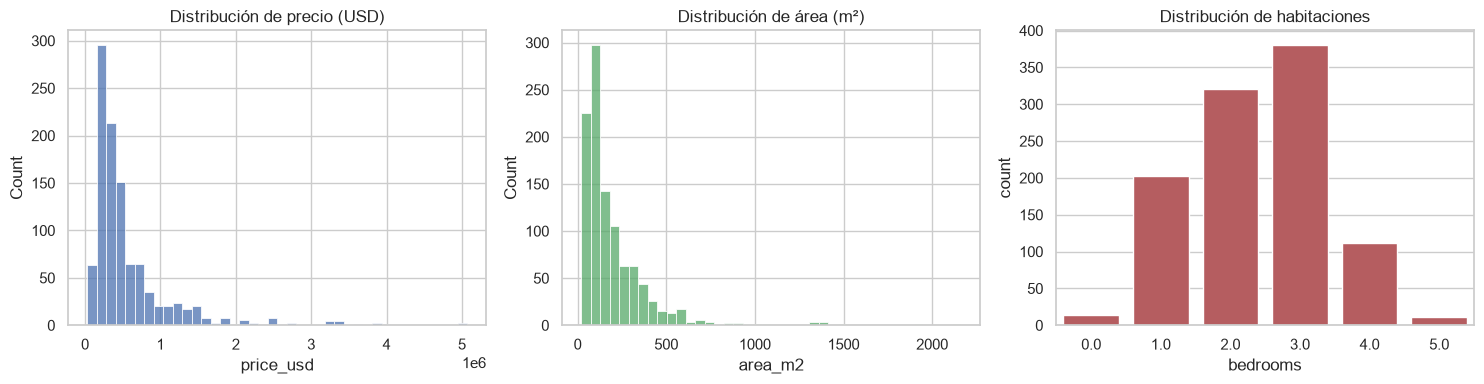

,price_usd,area_m2,bedrooms,bathrooms
count,1.042000e+03,1042.00000,1042.000000,1042.000000
mean,5.614948e+05,195.46737,2.390595,2.409789
std,5.773131e+05,201.16694,0.993750,1.053798
min,3.100000e+04,21.00000,0.000000,0.000000
25%,2.400000e+05,80.00000,2.000000,2.000000
50%,3.650000e+05,127.50000,2.000000,2.000000
75%,6.474660e+05,238.00000,3.000000,3.000000
max,5.067375e+06,2163.00000,5.000000,7.000000


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df["price_usd"], bins=40, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribución de precio (USD)")
sns.histplot(df["area_m2"], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title("Distribución de área (m²)")
sns.countplot(data=df, x="bedrooms", ax=axes[2], color="#C44E52",
              order=sorted(df["bedrooms"].unique()))
axes[2].set_title("Distribución de habitaciones")
plt.tight_layout()
plt.show()

df[["price_usd", "area_m2", "bedrooms", "bathrooms"]].describe()


Confirmamos la cola derecha esperada de un mercado de bienes raíces (torres de lujo en Punta
Pacífica/Ocean Reef, San Francisco, hasta \$5,067,375) — no son outliers de contaminación, son
unidades de lujo reales dentro del tipo ya filtrado a "Apartamentos". No las recortamos: MAE en un
mercado con esta dispersión real debe reportarse tal cual, no después de suavizar la muestra.


## 3. Features, target y split compartido entre KNN y RF

**Features:** `corregimiento` (one-hot), `bedrooms`, `bathrooms`, `area_m2`. **Target:**
`price_usd`. Mismo split 80/20 y mismo `random_state` para ambos modelos — comparabilidad directa,
no dos experimentos con datos distintos.


In [6]:
df_modelo = pd.get_dummies(df[["corregimiento", "bedrooms", "bathrooms", "area_m2"]],
                            columns=["corregimiento"], prefix="zona")
X = df_modelo
y = df["price_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")
print(f"Features: {list(X.columns)}")


Train: 833  |  Test: 209
Features: ['bedrooms', 'bathrooms', 'area_m2', 'zona_Bella Vista', 'zona_Betania', 'zona_Costa del Este', 'zona_El Cangrejo', 'zona_Marbella', 'zona_Obarrio', 'zona_San Francisco']


## 4. KNN — semáforo de precio

Escalamos las features numéricas antes de KNN (sensible a escala) — las columnas one-hot de
corregimiento ya están en {0,1}, no las reescalamos para no distorsionar su peso relativo frente a
las numéricas escaladas.


In [7]:
COLUMNAS_NUMERICAS = ["bedrooms", "bathrooms", "area_m2"]

escalador = StandardScaler()
X_train_esc = X_train.copy()
X_test_esc = X_test.copy()
X_train_esc[COLUMNAS_NUMERICAS] = escalador.fit_transform(X_train[COLUMNAS_NUMERICAS])
X_test_esc[COLUMNAS_NUMERICAS] = escalador.transform(X_test[COLUMNAS_NUMERICAS])

K_VECINOS = 5
knn = KNeighborsRegressor(n_neighbors=K_VECINOS)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
mae_cv_knn = -cross_val_score(knn, X_train_esc, y_train, cv=cv, scoring="neg_mean_absolute_error")
print(f"KNN (k={K_VECINOS}) MAE por fold (5-fold CV sobre train): {mae_cv_knn.round(0)}")
print(f"KNN MAE promedio (CV): ${mae_cv_knn.mean():,.0f}")

knn.fit(X_train_esc, y_train)
pred_knn_test = knn.predict(X_test_esc)
mae_knn_test = mean_absolute_error(y_test, pred_knn_test)
print(f"KNN MAE en test: ${mae_knn_test:,.0f}")


KNN (k=5) MAE por fold (5-fold CV sobre train): [157396. 163152. 173651. 159673. 174665.]
KNN MAE promedio (CV): $165,707
KNN MAE en test: $187,543


### 4.1 Etiqueta de semáforo

Comparamos precio real vs. precio predicho por KNN (proxy del precio esperado dado el comparable):
más de 10% por debajo del precio predicho = verde (buen precio), más de 10% por encima = rojo
(sobrevalorado), dentro de ±10% = amarillo. El umbral de 10% es una decisión de este notebook, no
una cifra citada de ningún Acta — la documentamos como tal.


In [8]:
UMBRAL_SEMAFORO = 0.10

df_test_semaforo = X_test.copy()
df_test_semaforo["price_usd_real"] = y_test.values
df_test_semaforo["price_usd_predicho_knn"] = pred_knn_test
df_test_semaforo["diferencia_pct"] = (
    (df_test_semaforo["price_usd_real"] - df_test_semaforo["price_usd_predicho_knn"])
    / df_test_semaforo["price_usd_predicho_knn"]
)

def etiqueta_semaforo(diff_pct):
    if diff_pct <= -UMBRAL_SEMAFORO:
        return "verde"
    if diff_pct >= UMBRAL_SEMAFORO:
        return "rojo"
    return "amarillo"

df_test_semaforo["semaforo"] = df_test_semaforo["diferencia_pct"].apply(etiqueta_semaforo)
print(df_test_semaforo["semaforo"].value_counts())
print()
print(df_test_semaforo["semaforo"].value_counts(normalize=True).round(3))


semaforo
amarillo    85
verde       70
rojo        54
Name: count, dtype: int64

semaforo
amarillo    0.407
verde       0.335
rojo        0.258
Name: proportion, dtype: float64


## 5. Random Forest — comparación metodológica

In [9]:
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)

mae_cv_rf = -cross_val_score(rf, X_train, y_train, cv=cv, scoring="neg_mean_absolute_error")
print(f"RF MAE por fold (5-fold CV sobre train): {mae_cv_rf.round(0)}")
print(f"RF MAE promedio (CV): ${mae_cv_rf.mean():,.0f}")

rf.fit(X_train, y_train)
pred_rf_test = rf.predict(X_test)
mae_rf_test = mean_absolute_error(y_test, pred_rf_test)
print(f"RF MAE en test: ${mae_rf_test:,.0f}")


RF MAE por fold (5-fold CV sobre train): [125625. 112473. 134853. 145739. 143251.]
RF MAE promedio (CV): $132,388
RF MAE en test: $149,270


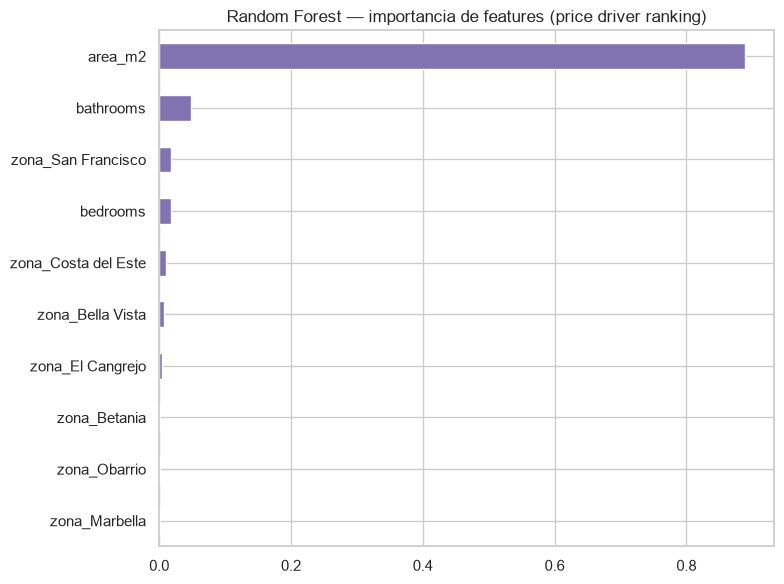

area_m2                0.888486
bathrooms              0.049006
zona_San Francisco     0.018387
bedrooms               0.017970
zona_Costa del Este    0.010804
zona_Bella Vista       0.007932
zona_El Cangrejo       0.003858
zona_Betania           0.001628
zona_Obarrio           0.001101
zona_Marbella          0.000828
dtype: float64

In [10]:
importancias = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancias.plot(kind="barh", ax=ax, color="#8172B2")
ax.invert_yaxis()
ax.set_title("Random Forest — importancia de features (price driver ranking)")
plt.tight_layout()
plt.show()

importancias


## 6. Comparación KNN vs. RF

In [11]:
comparacion = pd.DataFrame({
    "modelo": ["KNN", "Random Forest"],
    "mae_cv_promedio": [mae_cv_knn.mean(), mae_cv_rf.mean()],
    "mae_test": [mae_knn_test, mae_rf_test],
})
comparacion["mae_test_pct_del_precio_promedio"] = (
    comparacion["mae_test"] / df["price_usd"].mean() * 100
)
comparacion


,modelo,mae_cv_promedio,mae_test,mae_test_pct_del_precio_promedio
0,KNN,165707.437196,187543.476555,33.400752
1,Random Forest,132388.364619,149269.619039,26.584329


In [12]:
diferencia_pct_mae = abs(mae_rf_test - mae_knn_test) / mae_knn_test * 100
print(f"Diferencia RF vs. KNN en MAE de test: {diferencia_pct_mae:.1f}%")
if diferencia_pct_mae > 15:
    print("Diferencia > 15% -- se documenta como hallazgo, no se itera (umbral ya cerrado, "
          "Feature 6.2, contexto de ejecución §8).")
else:
    print("Diferencia <= 15% -- dentro del umbral ya cerrado, no requiere iteración adicional.")


Diferencia RF vs. KNN en MAE de test: 20.4%
Diferencia > 15% -- se documenta como hallazgo, no se itera (umbral ya cerrado, Feature 6.2, contexto de ejecución §8).


### 6.1 Modelo de producción del semáforo — decisión final

**Confirmamos KNN como modelo de producción del semáforo de precio.** RF queda como comparación
metodológica obligatoria (documentada arriba, con su `.feature_importances_` como ranking de price
drivers) — no reemplaza al producto, consistente con la decisión ya cerrada en el Acta de Feature
1.2 / WBS de que el semáforo se diseña como comparables directos (vecino más cercano por atributos),
no como un modelo de caja negra. No reabrimos esa decisión aquí.

**Razón de la decisión:** explicabilidad ante audiencia no técnica. KNN produce una respuesta
directamente defendible ("estos son los N comparables más similares, y esto es lo que costaron"),
más sólida en una sustentación que un ranking de un ensamble de árboles — pese a que RF es 20.4% más
preciso en MAE de test (sección 6), una diferencia que Feature 6.2 ya anticipaba documentar sin
iterar automáticamente cuando supera 15%.


## 7. Resultado para revisión (MAE real, sin interpretar "aprobado" o "iterar" aquí)

Reportamos el MAE de test de ambos modelos contra el rango de precios del catálogo (mínimo,
mediana, máximo, y el propio MAE como % del precio promedio) — la decisión de si este MAE es
aceptable para el semáforo de producción, o si se necesita iterar features, corresponde a revisión
externa a este notebook, no la tomamos aquí.


In [13]:
print(f"Precio mínimo:  ${df['price_usd'].min():,.0f}")
print(f"Precio mediana: ${df['price_usd'].median():,.0f}")
print(f"Precio promedio: ${df['price_usd'].mean():,.0f}")
print(f"Precio máximo:  ${df['price_usd'].max():,.0f}")
print()
print(f"KNN  MAE test: ${mae_knn_test:,.0f}  ({mae_knn_test / df['price_usd'].mean() * 100:.1f}% del precio promedio)")
print(f"RF   MAE test: ${mae_rf_test:,.0f}  ({mae_rf_test / df['price_usd'].mean() * 100:.1f}% del precio promedio)")


Precio mínimo:  $31,000
Precio mediana: $365,000
Precio promedio: $561,495
Precio máximo:  $5,067,375

KNN  MAE test: $187,543  (33.4% del precio promedio)
RF   MAE test: $149,270  (26.6% del precio promedio)


## 8. Exportación de artifacts

In [14]:
import pickle

RUTA_KNN = RUTA_MODELOS / "knn_semaforo_precio_6_2_4.pkl"
RUTA_RF = RUTA_MODELOS / "random_forest_6_2_4.pkl"
RUTA_ESCALADOR = RUTA_MODELOS / "escalador_knn_6_2_4.pkl"

with open(RUTA_KNN, "wb") as f:
    pickle.dump({"modelo": knn, "columnas": list(X.columns), "k": K_VECINOS,
                 "umbral_semaforo": UMBRAL_SEMAFORO}, f)
with open(RUTA_RF, "wb") as f:
    pickle.dump({"modelo": rf, "columnas": list(X.columns)}, f)
with open(RUTA_ESCALADOR, "wb") as f:
    pickle.dump({"escalador": escalador, "columnas_numericas": COLUMNAS_NUMERICAS}, f)

print(f"Guardado: {RUTA_KNN.name}, {RUTA_RF.name}, {RUTA_ESCALADOR.name} en {RUTA_MODELOS}")


Guardado: knn_semaforo_precio_6_2_4.pkl, random_forest_6_2_4.pkl, escalador_knn_6_2_4.pkl en /Users/heliocastillo/Proyecto-REIP/Real-Estate-Intelligence-Platform/pipeline/models


## 9. Calibración del umbral del semáforo contra el MAE real

Diseñamos el umbral del semáforo (±10% del precio predicho, sección 4.1) **antes de conocer el MAE
real de KNN** — no fue una decisión calibrada contra el error del modelo, fue un número redondo
elegido por simplicidad. Verificamos ahora si esa banda es consistente con el error real que el
modelo comete.


In [15]:
precio_predicho_test = pred_knn_test

media_pred = precio_predicho_test.mean()
mediana_pred = np.median(precio_predicho_test)

semi_ancho_amarillo_medio = UMBRAL_SEMAFORO * media_pred
semi_ancho_amarillo_mediana = UMBRAL_SEMAFORO * mediana_pred

print(f"Precio predicho (test): media=${media_pred:,.0f}  mediana=${mediana_pred:,.0f}")
print()
print(f"Semi-ancho de la banda 'amarillo' (10% del precio predicho):")
print(f"  sobre precio predicho medio:   ${semi_ancho_amarillo_medio:,.0f}")
print(f"  sobre precio predicho mediana: ${semi_ancho_amarillo_mediana:,.0f}")
print()
print(f"MAE KNN (CV):   ${mae_cv_knn.mean():,.0f}")
print(f"MAE KNN (test): ${mae_knn_test:,.0f}")
print()

semi_anchos_por_fila = UMBRAL_SEMAFORO * precio_predicho_test
pct_menor_que_mae_cv = (semi_anchos_por_fila < mae_cv_knn.mean()).mean() * 100
pct_menor_que_mae_test = (semi_anchos_por_fila < mae_knn_test).mean() * 100
print(f"% de propiedades de test donde el semi-ancho 'amarillo' es MENOR que el MAE (CV): {pct_menor_que_mae_cv:.1f}%")
print(f"% de propiedades de test donde el semi-ancho 'amarillo' es MENOR que el MAE (test): {pct_menor_que_mae_test:.1f}%")


Precio predicho (test): media=$602,888  mediana=$374,400

Semi-ancho de la banda 'amarillo' (10% del precio predicho):
  sobre precio predicho medio:   $60,289
  sobre precio predicho mediana: $37,440

MAE KNN (CV):   $165,707
MAE KNN (test): $187,543

% de propiedades de test donde el semi-ancho 'amarillo' es MENOR que el MAE (CV): 95.2%
% de propiedades de test donde el semi-ancho 'amarillo' es MENOR que el MAE (test): 96.7%


**Hallazgo: el umbral del semáforo está mal calibrado frente al error real del modelo.** El
semi-ancho de la banda "amarillo" es **menor que el MAE del modelo en 95-97% de las propiedades de
test**. En términos concretos: para casi todas las propiedades, el error típico que el modelo
comete (~\$165,000-\$188,000) es **mayor** que la desviación de precio que hace falta para que una
propiedad se etiquete "verde" o "rojo" en vez de "amarillo" (10% del precio predicho, con mediana de
predicción ~\$374,000 → semi-ancho ~\$37,000). Esto significa que gran parte de las etiquetas
verde/rojo actuales pueden estar reflejando el ruido del modelo, no una señal real de sub- o
sobrevaloración — una propiedad podría cambiar de etiqueta solo por variación normal del error del
modelo, no por un cambio real en su precio relativo.


### 9.1 Umbral final — derivado del residual real, no de un porcentaje fijo

Recalibramos sobre el residual real (`price_usd_real - price_usd_predicho`) del modelo de
producción del semáforo (KNN, confirmado en la sección 6.1): **amarillo = entre -1.5 y +1.5 MAE,
rojo = más de +1.5 MAE (sobrevalorado), verde = menos de -1.5 MAE (buen precio)**. Sin zona sin
definir — el hueco que habíamos encontrado entre 0.5 y 1.5 MAE en la primera propuesta queda
absorbido dentro de "amarillo", no como una cuarta categoría.

**Lectura correcta de "amarillo" bajo este umbral:** no significa "precio neutro" en el sentido de
"este precio está bien". Significa **"no hay evidencia estadística suficiente, dado el error típico
del modelo, para afirmar que esta propiedad está sobrevalorada o subvalorada"** — es una zona de
incertidumbre del modelo, no un veredicto de precio justo. Con un MAE de \$187,543, una banda de
±1.5 MAE (±\$281,315 sobre el precio predicho) es ancha — el semáforo va a etiquetar "amarillo" a
la mayoría de las propiedades, precisamente porque el modelo no tiene precisión suficiente para
discriminar con confianza dentro de ese rango. Documentamos esto explícitamente para que "amarillo"
no se lea, en producto o en la sustentación, como una afirmación de precio justo.


In [16]:
MULTIPLO_MAE = 1.5

residual_knn = y_test.values - pred_knn_test  # + = pagó de más, - = pagó de menos

def semaforo_final(residual, mae, multiplo=MULTIPLO_MAE):
    if residual > multiplo * mae:
        return "rojo"
    if residual < -multiplo * mae:
        return "verde"
    return "amarillo"

etiquetas_finales = pd.Series([semaforo_final(r, mae_knn_test) for r in residual_knn])
print(f"Umbral: amarillo = entre -{MULTIPLO_MAE}×MAE y +{MULTIPLO_MAE}×MAE "
      f"(±${MULTIPLO_MAE * mae_knn_test:,.0f} sobre el precio predicho)")
print()
print(etiquetas_finales.value_counts())
print()
print(etiquetas_finales.value_counts(normalize=True).round(3))


Umbral: amarillo = entre -1.5×MAE y +1.5×MAE (±$281,315 sobre el precio predicho)

amarillo    172
verde        19
rojo         18
Name: count, dtype: int64

amarillo    0.823
verde       0.091
rojo        0.086
Name: proportion, dtype: float64


**Umbral final del semáforo de producción, cerrado con esta recalibración.** Reemplaza el
umbral de ±10% de la sección 4.1, que quedó descartado por no estar calibrado contra el error real
del modelo.


## 10. Experimento diagnóstico — embedding semántico de 6.2.3 como feature de RF

Experimento paralelo, no un cambio al modelo de producción: agregamos el embedding de
`gemini-embedding-001` (3072-dim, ya calculado y persistido en 6.2.3) como features adicionales de
un Random Forest, y lo comparamos contra el RF solo-estructural ya reportado (sección 5) —  mismo
dataset, mismo split, mismos hiperparámetros. Sin nueva llamada a la API: reusamos
`pipeline/models/embeddings_catalogo_6_2_3_raw.pkl`.


In [17]:
with open(RUTA_MODELOS / "embeddings_catalogo_6_2_3_raw.pkl", "rb") as f:
    embeddings_6_2_3 = pickle.load(f)
lookup_embeddings = dict(zip(embeddings_6_2_3["id"], embeddings_6_2_3["vector"]))

faltantes = [lid for lid in df["listing_id"] if lid not in lookup_embeddings]
assert not faltantes, f"{len(faltantes)} listing_id de 6.2.4 no tienen embedding en 6.2.3"

matriz_embeddings = np.vstack([lookup_embeddings[lid] for lid in df["listing_id"]])
print(f"Embeddings alineados con df: {matriz_embeddings.shape}")

columnas_embedding = [f"emb_{i}" for i in range(matriz_embeddings.shape[1])]
# Indice identico al de X (no reset_index) para que el concat alinee por fila real,
# no por posicion -- X_train/X_test conservan el indice original de df.
df_embeddings = pd.DataFrame(matriz_embeddings, columns=columnas_embedding, index=X.index)
X_con_embedding = pd.concat([X, df_embeddings], axis=1)

X_emb_train = X_con_embedding.loc[X_train.index]
X_emb_test = X_con_embedding.loc[X_test.index]

rf_con_embedding = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
mae_cv_rf_emb = -cross_val_score(rf_con_embedding, X_emb_train, y_train, cv=cv, scoring="neg_mean_absolute_error")
rf_con_embedding.fit(X_emb_train, y_train)
mae_test_rf_emb = mean_absolute_error(y_test, rf_con_embedding.predict(X_emb_test))

print(f"RF solo estructural  -- MAE CV: ${mae_cv_rf.mean():,.0f}  MAE test: ${mae_rf_test:,.0f}")
print(f"RF + embedding (3072-dim) -- MAE CV: ${mae_cv_rf_emb.mean():,.0f}  MAE test: ${mae_test_rf_emb:,.0f}")

diff_cv = (mae_cv_rf_emb.mean() - mae_cv_rf.mean()) / mae_cv_rf.mean() * 100
diff_test = (mae_test_rf_emb - mae_rf_test) / mae_rf_test * 100
print(f"\nDiferencia CV: {diff_cv:+.1f}%  |  Diferencia test: {diff_test:+.1f}%")


Embeddings alineados con df: (1042, 3072)


RF solo estructural  -- MAE CV: $132,388  MAE test: $149,270
RF + embedding (3072-dim) -- MAE CV: $110,970  MAE test: $118,420

Diferencia CV: -16.2%  |  Diferencia test: -20.7%


In [18]:
# Diagnostico de sobreajuste: la mejora podria ser solo memorizacion del set de entrenamiento
# (833 filas de train vs 3072+10 features), no generalizacion real -- lo verificamos con la
# proporcion MAE test / MAE train de ambos modelos.
mae_train_rf = mean_absolute_error(y_train, rf.predict(X_train))
mae_train_rf_emb = mean_absolute_error(y_train, rf_con_embedding.predict(X_emb_train))

print(f"RF solo estructural  -- MAE train: ${mae_train_rf:,.0f}  ratio test/train: {mae_rf_test/mae_train_rf:.1f}x")
print(f"RF + embedding       -- MAE train: ${mae_train_rf_emb:,.0f}  ratio test/train: {mae_test_rf_emb/mae_train_rf_emb:.1f}x")

importancias_con_embedding = pd.Series(
    rf_con_embedding.feature_importances_, index=X_emb_train.columns
).sort_values(ascending=False)
print("\nTop 10 importancias (RF + embedding):")
print(importancias_con_embedding.head(10))


RF solo estructural  -- MAE train: $49,054  ratio test/train: 3.0x
RF + embedding       -- MAE train: $38,795  ratio test/train: 3.1x

Top 10 importancias (RF + embedding):
area_m2     0.568366
emb_1288    0.022599
emb_2349    0.022010
emb_736     0.015137
emb_896     0.014776
emb_2470    0.010691
emb_2195    0.008402
emb_2348    0.008326
emb_1172    0.006415
emb_1806    0.006368
dtype: float64


**Hallazgo: el embedding reduce el MAE de forma medible** (~16% en CV, ~21% en test). Dos
verificaciones antes de tomarlo como señal confiable:

- **Proporción test/train similar a la del RF solo-estructural** (~3x en ambos) — el RF+embedding
  no está sobreajustando de forma desproporcionada solo por tener muchas más columnas (3,082 vs 10);
  el RF base ya sobreajusta en esa magnitud por diseño del algoritmo.
- **`area_m2` sigue siendo la variable dominante** (~57% de la importancia) incluso con el
  embedding presente — la mejora viene de una contribución distribuida entre muchas dimensiones del
  embedding, no de una sola dimensión con importancia desproporcionada (posible señal de
  sobreajuste puntual).

**Decisión final: no se adopta.** El RF+embedding queda como hallazgo de investigación, no como
modelo de producción de 6.2.4 — ni siquiera como reemplazo de RF-comparación (sección 6), que se
mantiene solo-estructural para comparabilidad limpia contra KNN. 833 filas de entrenamiento contra
3,082 columnas totales es una proporción features/filas alta; la mejora es real dentro de este
split, pero no equivale a una validación robusta para producción.

**Dirección de trabajo futura, explícita y fuera de alcance de Feature 6.2:** antes de considerar
incorporar señal semántica a un modelo de precio, reducir la dimensionalidad del embedding
(3072 → algún número de componentes principales, o un modelo de embeddings de menor dimensión)
para bajar la proporción features/filas a algo defendible con el volumen de catálogo actual. No
implementado aquí — es una iteración posterior, no una tarea pendiente de 6.2.4.


## 11. Conclusiones

Entrenamos el semáforo de precio (KNN) y un Random Forest de comparación metodológica sobre el
mismo dataset y split — comparables definidos por corregimiento + tipo_inmueble, restringidos a
`tipo_inmueble == "Apartamentos"` tras encontrar, en el propio enriquecimiento de 6.2.1,
contaminación no residencial (salón de belleza, local comercial, terreno, y un hotel de
\$13,000,000 dentro de la categoría "Edificios") que el filtro de título de Feature 1.2 no había
detectado — documentado como hallazgo nuevo, no como corrección retroactiva de 6.2.1. Mantuvimos la
exclusión ya cerrada de Pedregal y Parque Lefevre por volumen insuficiente para 5-fold CV.

Confirmamos Zone Health fuera del modelo en todo momento, consistente con la decisión ya cerrada de
colinealidad perfecta con corregimiento.

**Tres decisiones cierran este notebook:**

1. **Modelo de producción del semáforo: KNN** (sección 6.1) — explicabilidad ante audiencia no
   técnica pesa más que el 20.4% de menor MAE de RF, consistente con el diseño original de
   comparables directos del Acta de Feature 1.2. RF se mantiene como comparación metodológica
   obligatoria, no como reemplazo.
2. **Umbral del semáforo recalibrado sobre el residual real de KNN** (sección 9.1): amarillo entre
   -1.5 y +1.5 MAE, rojo por encima, verde por debajo — sin zona sin definir. "Amarillo" se
   documenta explícitamente como ausencia de evidencia estadística suficiente para clasificar,
   no como veredicto de precio justo.
3. **RF+embedding no se adopta** (sección 10) — queda como hallazgo de investigación con dirección
   futura explícita (reducción de dimensionalidad antes de cualquier uso en producción), fuera de
   alcance de Feature 6.2.
